In [1]:
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPool2D, Conv2DTranspose, Concatenate, Input
from tensorflow.keras.models import Model

In [3]:
def convulution_block(inputs, num_filters): #input = input feature map and num_filters = number of feature channels
    x = Conv2D(num_filters, 3, padding="same")(inputs) #(no_of_filters, kernal size, padding)
    x = BatchNormalization()(x) #The input of the bacth normalization will be the output of Conv2D
    x = Activation("relu")(x) #relu is a non- linear activation fucntion

    x = Conv2D(num_filters, 3, padding="same")(x) #(no_of_filters, kernal size, padding)
    x = BatchNormalization()(x) #The input of the bacth normalization will be the output of Conv2D
    x = Activation("relu")(x) #relu is a non- linear activation fucntion

    return x

def contracting_path(inputs, num_filters):
    x = convulution_block(inputs, num_filters) # output of convulution layer
    p = MaxPool2D((2, 2))(x) # maxpool output
    return x, p

def expansive_path(inputs, concat_input, num_filters):
    x = Conv2DTranspose(num_filters, (2, 2), strides=2, padding="same")(inputs)
    x = Concatenate()([x, concat_input])
    x = convulution_block(x, num_filters)
    return x


def UNET(input_shape):
    inputs = Input(input_shape)
    no_of_filters = 64
    concat_info1, pool1 = contracting_path(inputs, no_of_filters)
    concat_info2, pool2 = contracting_path(pool1 , no_of_filters * 2)
    concat_info3, pool3 = contracting_path(pool2, no_of_filters * 4)
    concat_info4, pool4 = contracting_path(pool3, no_of_filters * 8)

    # print(concat_info1.shape, concat_info2.shape, concat_info3.shape, concat_info4.shape)
    # print(pool1.shape ,pool2.shape, pool3.shape, pool4.shape)

    bridge1 = convulution_block(pool4, no_of_filters * 16)


    d1 = expansive_path(bridge1, concat_info4, no_of_filters * 8)
    d2 = expansive_path(d1, concat_info3, no_of_filters * 4)
    d3 = expansive_path(d2, concat_info2, no_of_filters * 2)
    d4 = expansive_path(d3, concat_info1, no_of_filters)

    outputs = Conv2D(1, 1, padding="same", activation="sigmoid")(d4)
    #print(outputs.shape) #here this shape is the shape of the required mask
    model = Model(inputs, outputs, name="UNET")
    return model

# if __name__ == "__main__":
#     input_shape = (256, 256, 3)
#     model = UNET(input_shape)
#     model.summary()


In [4]:
import tensorflow as tf
import tensorflow.keras.backend as K

def mean_iou(y_true, y_pred, num_classes=2):
    y_true = tf.argmax(y_true, axis=-1)
    y_pred = tf.argmax(y_pred, axis=-1)

    iou_scores = []
    for i in range(num_classes):
        y_true_class = tf.cast(tf.equal(y_true, i), tf.float32)
        y_pred_class = tf.cast(tf.equal(y_pred, i), tf.float32)

        intersection = tf.reduce_sum(y_true_class * y_pred_class)
        union = tf.reduce_sum(y_true_class) + tf.reduce_sum(y_pred_class) - intersection
        iou = (intersection + 1e-7) / (union + 1e-7)
        iou_scores.append(iou)

    return tf.reduce_mean(iou_scores)


In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import backend as K

smooth = 1e-15
def dice_coef(y_true, y_pred, smooth=1e-6):
    # Ensure both y_true and y_pred are of type float32
    y_true = tf.cast(tf.keras.layers.Flatten()(y_true), tf.float32)
    y_pred = tf.cast(tf.keras.layers.Flatten()(y_pred), tf.float32)
    
    intersection = tf.reduce_sum(y_true * y_pred)
    
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)

In [6]:
def pixel_accuracy(y_true, y_pred):
    y_true = tf.argmax(y_true, axis=-1)
    y_pred = tf.argmax(y_pred, axis=-1)

    correct_predictions = tf.reduce_sum(tf.cast(tf.equal(y_true, y_pred), tf.int64))
    total_pixels = tf.size(y_true, out_type=tf.int64)

    return correct_predictions / total_pixels

In [7]:
import os
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from skimage.transform import resize
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import numpy as np
import cv2
from glob import glob
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, ReduceLROnPlateau, EarlyStopping, TensorBoard
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split


H, W, C = 128, 128, 3


train_image_path = "/kaggle/input/plantseg/plantsegv2/images/train"
train_mask_path = "/kaggle/input/plantseg/plantsegv2/annotations/train"

test_image_path = "/kaggle/input/plantseg/plantsegv2/images/test"
test_mask_path = "/kaggle/input/plantseg/plantsegv2/annotations/test"

val_image_path = "/kaggle/input/plantseg/plantsegv2/images/val"
val_mask_path = "/kaggle/input/plantseg/plantsegv2/annotations/val"

train_image_path_dir = train_image_path
train_mask_path_dir = train_mask_path

test_image_path_dir = test_image_path
test_mask_path_dir = test_mask_path

val_image_path_dir = val_image_path
val_mask_path_dir = val_mask_path



train_images = os.listdir(train_image_path_dir)
train_masks = os.listdir(train_mask_path_dir)

test_images = os.listdir(test_image_path_dir)
test_masks = os.listdir(test_mask_path_dir)

val_images = os.listdir(val_image_path_dir)
val_masks = os.listdir(val_mask_path_dir)

x_train = np.zeros((len(train_images), H, W, C), dtype=np.uint8)
y_train = np.zeros((len(train_masks), H, W, 1), dtype=np.uint8)



x_val = np.zeros((len(val_images), H, W, C), dtype=np.uint8)
y_val = np.zeros((len(val_masks), H, W, 1), dtype=np.uint8)


for i, file in tqdm(enumerate(train_images), total=len(train_images)):
    img_path = os.path.join(train_image_path_dir, file)
    mask_path = os.path.join(train_mask_path_dir, file.replace("jpg", "png"))

    img = Image.open(img_path).convert("RGB")
    img = np.array(img)
    mask = np.array(Image.open(mask_path).convert("L"))

    x_train[i] = resize(img, (H, W), mode="constant", preserve_range=True)
    y_train[i] = resize(mask, (H, W, 1), mode="constant", preserve_range=True)>0




100%|██████████| 7916/7916 [36:37<00:00,  3.60it/s]  


In [8]:
x_test = np.zeros((len(test_images), H, W, C), dtype=np.uint8)
y_test = np.zeros((len(test_masks), H, W, 1), dtype=np.uint8)

for i, file in tqdm(enumerate(test_images), total=len(test_images)):
    img_path = os.path.join(test_image_path_dir, file)
    mask_path = os.path.join(test_mask_path_dir, file.replace("jpg", "png"))

    img = Image.open(img_path).convert("RGB")
    img = np.array(img)
    mask = np.array(Image.open(mask_path).convert("L"))

    x_test[i] = resize(img, (H, W), mode="constant", preserve_range=True)
    y_test[i] = resize(mask, (H, W, 1), mode="constant", preserve_range=True)>0

100%|██████████| 2295/2295 [11:03<00:00,  3.46it/s] 


In [9]:
for i, file in tqdm(enumerate(val_images), total=len(val_images)):
    img_path = os.path.join(val_image_path_dir, file)
    mask_path = os.path.join(val_mask_path_dir, file.replace("jpg", "png"))

    img = Image.open(img_path).convert("RGB")
    img = np.array(img)
    mask = np.array(Image.open(mask_path).convert("L"))

    x_val[i] = resize(img, (H, W), mode="constant", preserve_range=True)
    y_val[i] = resize(mask, (H, W, 1), mode="constant", preserve_range=True)>0

100%|██████████| 1247/1247 [05:50<00:00,  3.55it/s]


In [18]:
def create_directory(path):
    
    if not os.path.exists(path):
        os.makedirs(path)


create_directory("files")

csv_path = os.path.join("files", "log.csv")
model_path = os.path.join("files", "model.keras")
model_path_2 = os.path.join("files", "model_2.keras")
lr = 1e-3

In [19]:
""" Hyperparameters """
batch_size = 16
lr = 1e-3  #learning rate
num_epochs = 30
model_path = os.path.join("files", "model.keras")
csv_path = os.path.join("files", "log.csv")

from tensorflow.keras.metrics import MeanIoU
iou_metric = MeanIoU(num_classes=2)

In [14]:
model = UNET((128, 128, 3))

model.compile(loss="binary_crossentropy", optimizer=Adam(lr), metrics=[dice_coef, iou_metric, "accuracy"])
    #uporer line e ami just dice_coef use korsi but eikahe if mean IOU and pixel_accuracy o use kroa lagbe
model.summary()
callbacks = [
    
    ModelCheckpoint(model_path, monitor='val_loss', verbose=1, save_best_only=True),
    CSVLogger(csv_path),
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=False),
     ]

model.fit(
 x_train, y_train,
 epochs=num_epochs,
 validation_data=(x_val, y_val),
 callbacks=callbacks
)

Model: "UNET"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 128, 64)   │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 128, 128, 64)   │            256 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 128, 128, 64)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 128, 128, 64)   │         36,928 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 128, 128, 64)   │            256 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 128, 128, 64)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 64, 64, 64)     │              0 │ activation_1[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 64, 64, 128)    │         73,856 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 64, 64, 128)    │            512 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 64, 64, 128)    │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 64, 64, 128)    │        147,584 │ activation_2[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 64, 64, 128)    │            512 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 64, 64, 128)    │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 32, 32, 128)    │              0 │ activation_3[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 32, 32, 256)    │        295,168 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4

 Total params: 31,055,297 (118.47 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

Epoch 1/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.7302 - dice_coef: 0.3916 - loss: 0.5327 - mean_io_u: 0.2845
Epoch 1: val_loss improved from inf to 0.66395, saving model to files/model.keras
248/248 ━━━━━━━━━━━━━━━━━━━━ 109s 304ms/step - accuracy: 0.7303 - dice_coef: 0.3917 - loss: 0.5325 - mean_io_u: 0.2844 - val_accuracy: 0.7649 - val_dice_coef: 0.3799 - val_loss: 0.6639 - val_mean_io_u: 0.3690
Epoch 2/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.7827 - dice_coef: 0.4653 - loss: 0.4539 - mean_io_u: 0.2832
Epoch 2: val_loss did not improve from 0.66395
248/248 ━━━━━━━━━━━━━━━━━━━━ 51s 204ms/step - accuracy: 0.7827 - dice_coef: 0.4653 - loss: 0.4539 - mean_io_u: 0.2831 - val_accuracy: 0.7408 - val_dice_coef: 0.1678 - val_loss: 0.9003 - val_mean_io_u: 0.3690
Epoch 3/30
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.7985 - dice_coef: 0.4872 - loss: 0.4289 - mean_io_u: 0.2855
Epoch 3: val_loss improved from 0.66395 to 0.53901, saving model to fi

In [17]:
results = model.evaluate(x_test, y_test)
print(results)

72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.8497 - dice_coef: 0.6375 - loss: 0.4100 - mean_io_u: 0.3526
[0.4035327136516571, 0.6415889263153076, 0.3116728663444519, 0.8519549369812012]


In [21]:
results = model.evaluate(x_test, y_test)
print(results)

72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - accuracy: 0.8497 - dice_coef: 0.6375 - loss: 0.4100 - mean_io_u: 0.3526
[0.4035327136516571, 0.6415889263153076, 0.3116728663444519, 0.8519549369812012]


In [26]:
from tensorflow.keras.utils import CustomObjectScope

model_path = "/kaggle/working/files/model.keras"
with CustomObjectScope({"dice_coef": dice_coef, "mean_iou" : mean_iou}):
    testing_model = tf.keras.models.load_model(model_path)
testing_model.summary()

TypeError: Could not locate function 'pixel_accuracy'. Make sure custom classes are decorated with `@keras.saving.register_keras_serializable()`. Full object config: {'module': 'builtins', 'class_name': 'function', 'config': 'pixel_accuracy', 'registered_name': 'function'}

In [28]:
model_path_3 = os.path.join("files", "model_3.keras")
csv_1_path = os.path.join("files", "logUpdate.csv")

model_3 = UNET((128, 128, 3))

model_3.compile(loss="binary_crossentropy", optimizer=Adam(lr), metrics=[dice_coef, iou_metric, "accuracy"])
    #uporer line e ami just dice_coef use korsi but eikahe if mean IOU and pixel_accuracy o use kroa lagbe
model.summary()
callbacks = [
    
    ModelCheckpoint(model_path_3, monitor='val_loss', verbose=1, save_best_only=True),
    CSVLogger(csv_1_path),
    EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=False),
     ]

model.fit(
 x_train, y_train,
 epochs=20,
 validation_data=(x_val, y_val),
 callbacks=callbacks
)

Model: "UNET"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 128, 64)   │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 128, 128, 64)   │            256 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 128, 128, 64)   │              0 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 128, 128, 64)   │         36,928 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 128, 128, 64)   │            256 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 128, 128, 64)   │              0 │ batch_normalization_1… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 64, 64, 64)     │              0 │ activation_1[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 64, 64, 128)    │         73,856 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 64, 64, 128)    │            512 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_2 (Activation) │ (None, 64, 64, 128)    │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 64, 64, 128)    │        147,584 │ activation_2[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 64, 64, 128)    │            512 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_3 (Activation) │ (None, 64, 64, 128)    │              0 │ batch_normalization_3… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 32, 32, 128)    │              0 │ activation_3[0][0]     │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 32, 32, 256)    │        295,168 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4

 Total params: 93,142,341 (355.31 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

 Optimizer params: 62,087,044 (236.84 MB)

Epoch 1/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9379 - dice_coef: 0.8317 - loss: 0.1510 - mean_io_u: 0.2845
Epoch 1: val_loss improved from inf to 0.36491, saving model to files/model_3.keras
248/248 ━━━━━━━━━━━━━━━━━━━━ 53s 212ms/step - accuracy: 0.9379 - dice_coef: 0.8317 - loss: 0.1511 - mean_io_u: 0.2844 - val_accuracy: 0.8559 - val_dice_coef: 0.6651 - val_loss: 0.3649 - val_mean_io_u: 0.3690
Epoch 2/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9414 - dice_coef: 0.8430 - loss: 0.1423 - mean_io_u: 0.2838
Epoch 2: val_loss did not improve from 0.36491
248/248 ━━━━━━━━━━━━━━━━━━━━ 51s 204ms/step - accuracy: 0.9414 - dice_coef: 0.8430 - loss: 0.1423 - mean_io_u: 0.2837 - val_accuracy: 0.8573 - val_dice_coef: 0.6903 - val_loss: 0.3859 - val_mean_io_u: 0.3739
Epoch 3/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9430 - dice_coef: 0.8466 - loss: 0.1385 - mean_io_u: 0.2837
Epoch 3: val_loss did not improve from 0.36491
248/248 ━━━━━━━━━━━━━━

In [29]:
results = model_3.evaluate(x_test, y_test)
print(results)

72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.7230 - dice_coef: 0.0057 - loss: 5.8209 - mean_io_u_1: 0.3526
[5.76036262512207, 0.005849831737577915, 0.3116728663444519, 0.7239913940429688]


In [30]:
results_0 = model.evaluate(x_test, y_test)
print(results_0)

72/72 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - accuracy: 0.8627 - dice_coef: 0.7240 - loss: 0.5136 - mean_io_u: 0.3544
[0.5068479180335999, 0.7270236611366272, 0.3138545751571655, 0.8646023273468018]


In [31]:
preds = model.predict(x_test)

72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step


In [32]:
preds_3 = model_3.predict(x_test)

72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 74ms/step


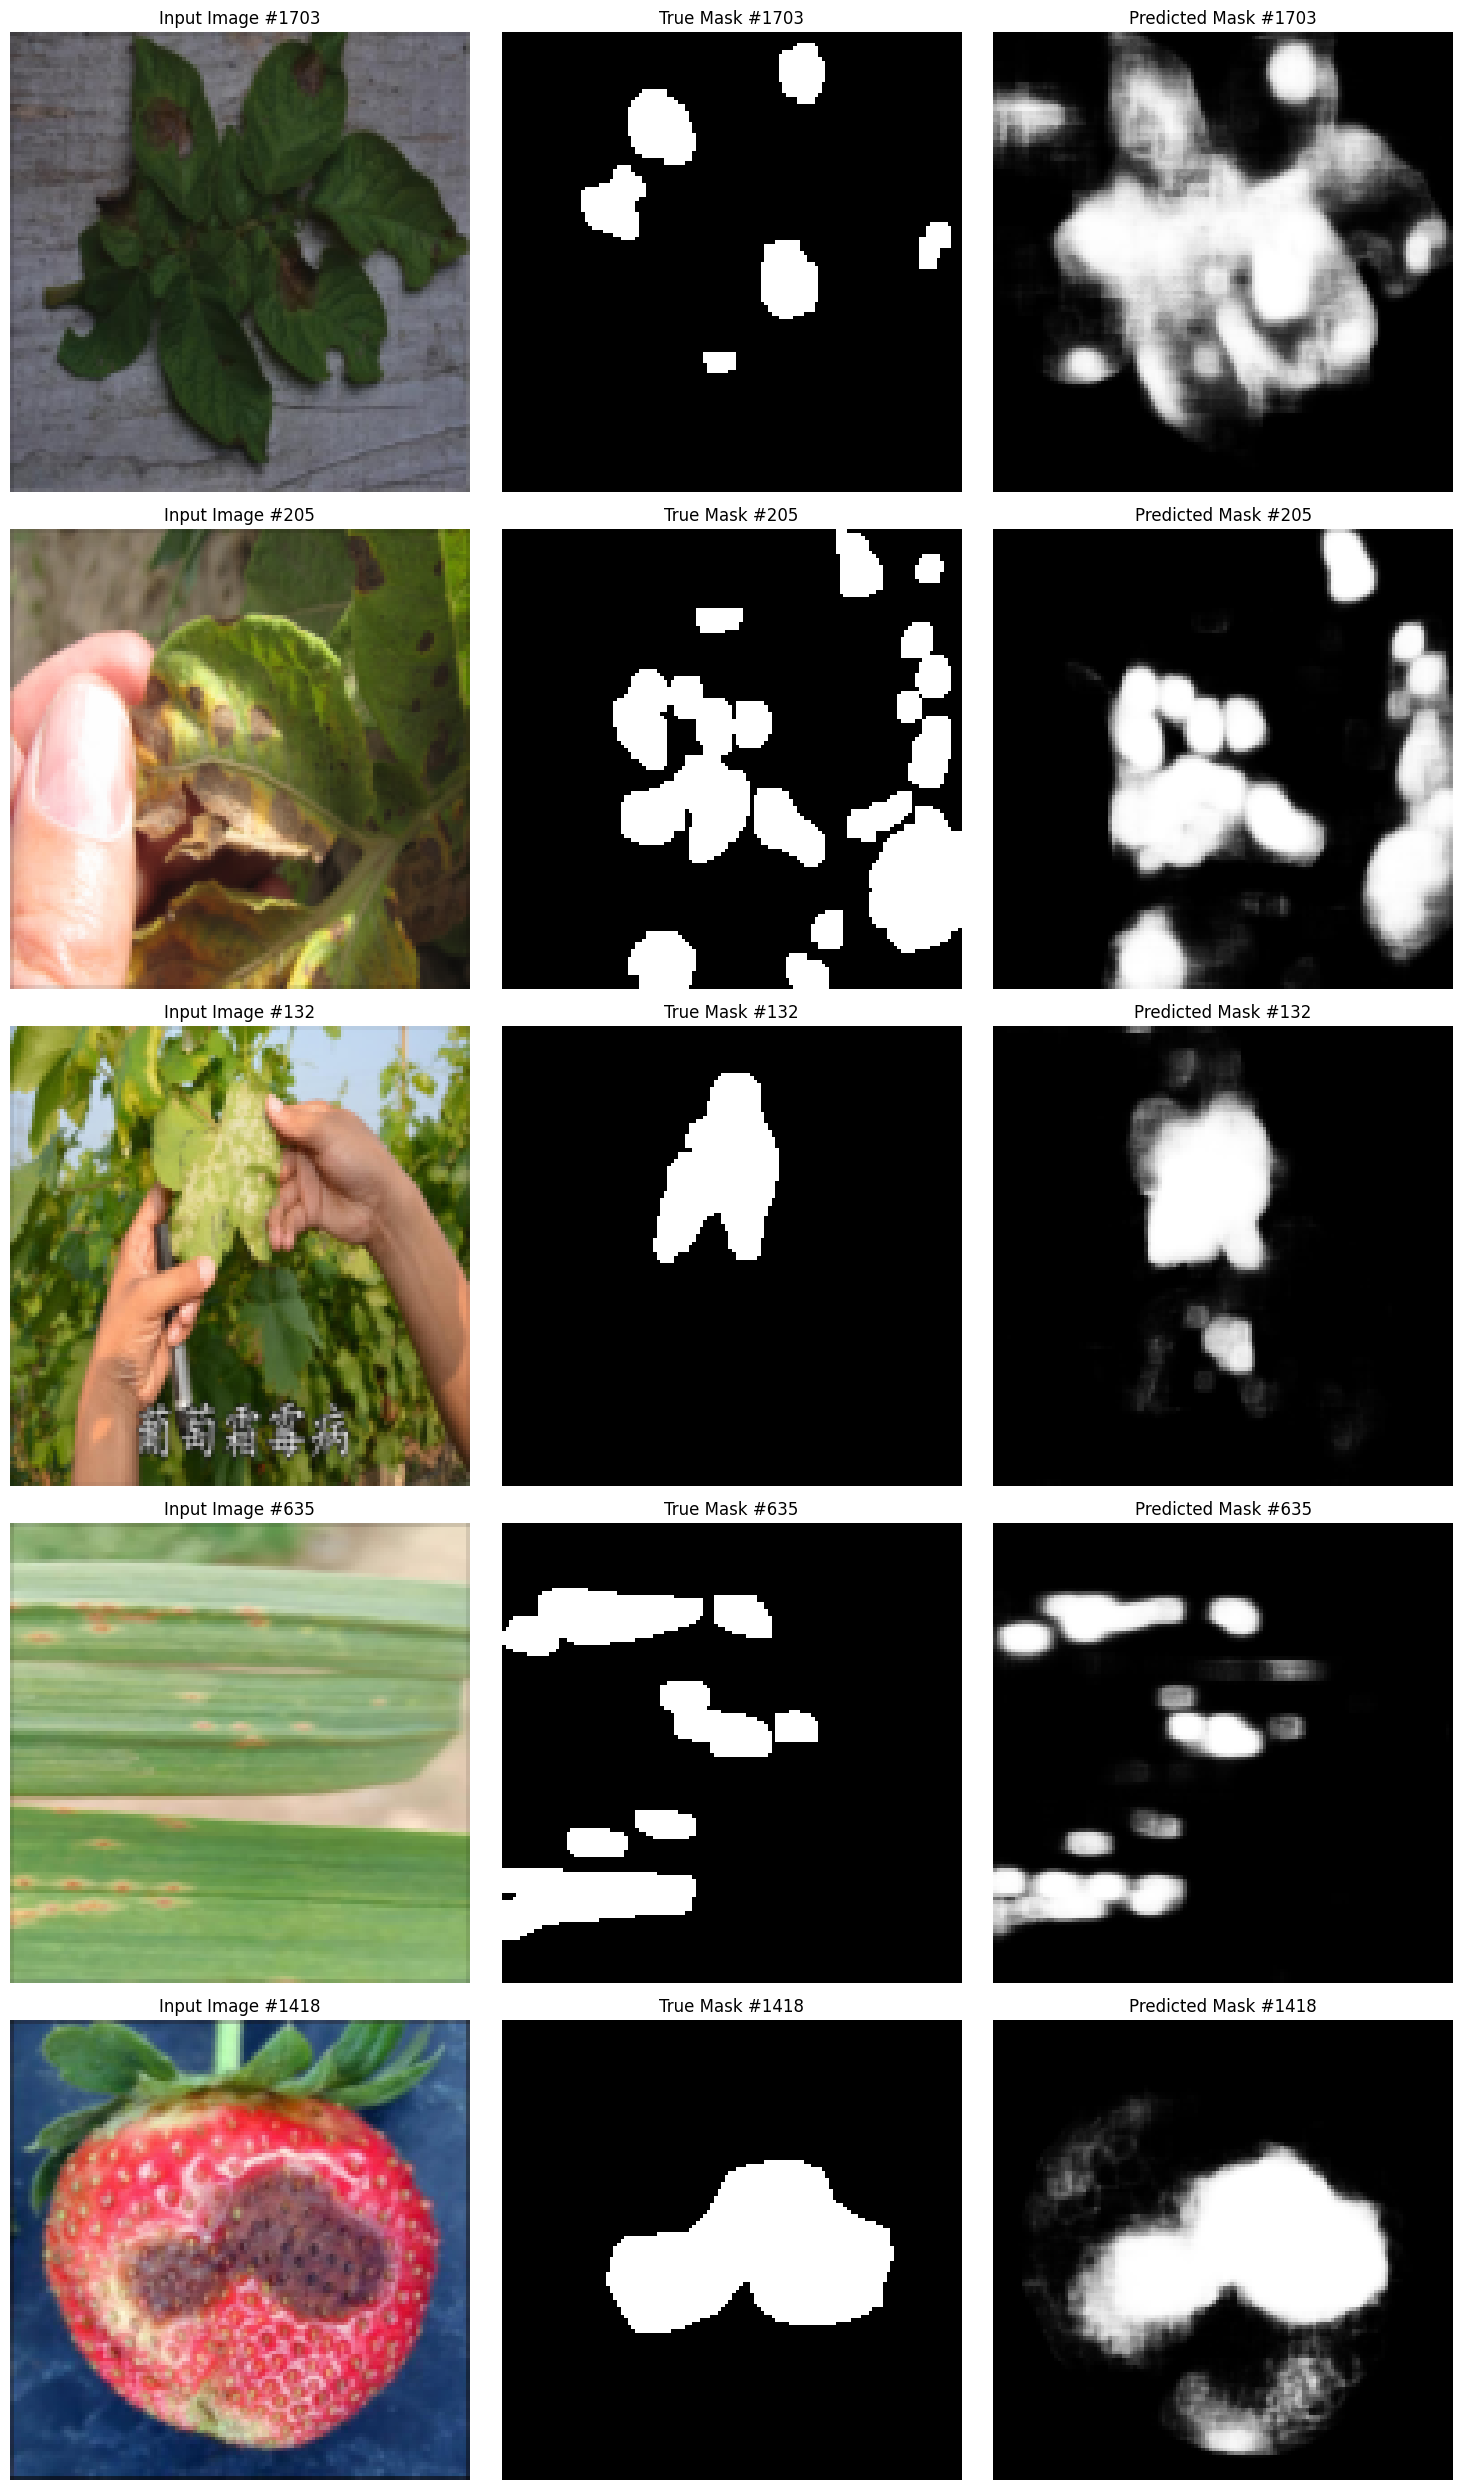

In [35]:
import matplotlib.pyplot as plt
import random

def visualize_results(X_test, Y_test, pred_mask, sample_count=5):
    """
    Visualize the input images, true masks, and predicted masks.

    Args:
        X_test (numpy array): Test images.
        Y_test (numpy array): Ground truth masks.
        pred_mask (numpy array): Predicted masks.
        sample_count (int): Number of samples to visualize.
    """
    # Ensure masks are squeezed if necessary
    pred_mask = np.squeeze(pred_mask)
    Y_test = np.squeeze(Y_test)

    # Randomly pick sample_count indices from the test set
    indices = random.sample(range(len(X_test)), sample_count)

    plt.figure(figsize=(15, sample_count * 5))

    for i, idx in enumerate(indices):
        # Test image
        plt.subplot(sample_count, 3, i * 3 + 1)
        plt.imshow(X_test[idx])
        plt.title(f"Input Image #{idx}")
        plt.axis('off')

        # True mask
        plt.subplot(sample_count, 3, i * 3 + 2)
        plt.imshow(Y_test[idx], cmap='gray')
        plt.title(f"True Mask #{idx}")
        plt.axis('off')

        # Predicted mask
        plt.subplot(sample_count, 3, i * 3 + 3)
        plt.imshow(pred_mask[idx], cmap='gray')
        plt.title(f"Predicted Mask #{idx}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Visualize 5 random samples
visualize_results(x_test, y_test, preds, sample_count=5)


In [ ]:

demo_image_path = "/kaggle/input/428-demo-pics/Demo pics"
demo_image_path_dir = demo_image_path

demo_images = os.listdir(demo_image_path_dir)


final_demo = np.zeros((len(demo_images), H, W, C), dtype=np.uint8)


for i, file in tqdm(enumerate(demo_images), total=len(demo_images)):
    img_path = os.path.join(demo_image_path_dir, file)
    

    img = Image.open(img_path).convert("RGB")
    img = np.array(img)
    

    final_demo[i] = resize(img, (H, W), mode="constant", preserve_range=True)
    



 50%|█████     | 3/6 [00:00<00:00, 23.53it/s]

In [ ]:
import matplotlib.pyplot as plt
import random

def visualize_results(X_test, Y_test, pred_mask, sample_count=5):
    """
    Visualize the input images, true masks, and predicted masks.

    Args:
        X_test (numpy array): Test images.
        Y_test (numpy array): Ground truth masks.
        pred_mask (numpy array): Predicted masks.
        sample_count (int): Number of samples to visualize.
    """
    # Ensure masks are squeezed if necessary
    pred_mask = np.squeeze(pred_mask)
    Y_test = np.squeeze(Y_test)

    # Randomly pick sample_count indices from the test set
    indices = random.sample(range(len(X_test)), sample_count)

    plt.figure(figsize=(15, sample_count * 5))

    for i, idx in enumerate(indices):
        # Test image
        plt.subplot(sample_count, 3, i * 3 + 1)
        plt.imshow(X_test[idx])
        plt.title(f"Input Image #{idx}")
        plt.axis('off')

        # True mask
        plt.subplot(sample_count, 3, i * 3 + 2)
        plt.imshow(Y_test[idx], cmap='gray')
        plt.title(f"True Mask #{idx}")
        plt.axis('off')

        # Predicted mask
        plt.subplot(sample_count, 3, i * 3 + 3)
        plt.imshow(pred_mask[idx], cmap='gray')
        plt.title(f"Predicted Mask #{idx}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Visualize 5 random samples
visualize_results(X_test, Y_test, pred_mask, sample_count=5)


In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import cv2
import pandas as pd
from glob import glob
from tqdm import tqdm # Progress bar
import tensorflow as tf
from tensorflow.keras.utils import CustomObjectScope
from sklearn.model_selection import train_test_split



def create_directory(path):
    if not os.path.exists(path):
        os.makedirs(path)


def save_result(image, mask, y_pred, save_image_path):

    image = cv2.resize(image,(W,H))
    mask = cv2.resize(mask,(W,H))
    y_pred = cv2.resize(y_pred,(W,H))
    
    # here, image has 3 channels while mask and y_pred has 1 channel
    mask = np.expand_dims( mask, axis =-1)
    y_pred = np.expand_dims(y_pred, axis=-1)
    
    mask = np.concatenate([mask, mask, mask], axis=-1) # transforming channel 1 to 3
    y_pred = np.concatenate([y_pred, y_pred, y_pred], axis=-1) # transforming channel 1 to 3
    y_pred = y_pred * 255 # prediction range was 0-1 to making it 0-255
    line = np.ones((H, 10, 3)) * 255
    total_concat = np.concatenate([image,line, mask, line, y_pred], axis=1)
    cv2.imwrite(save_image_path, total_concat)

def load_dataset():
    image_path = "/kaggle/input/plantseg/plantsegv2/images"
    mask_path = "/kaggle/input/plantseg/plantsegv2/annotations"

 
    train_images = sorted(glob(os.path.join(image_path, "train", "*.jpg")))
    train_masks = sorted(glob(os.path.join(mask_path, "train", "*.png")))

    test_images = sorted(glob(os.path.join(image_path, "test", "*.jpg")))
    test_masks = sorted(glob(os.path.join(mask_path, "test", "*.png")))

    val_images = sorted(glob(os.path.join(image_path, "val", "*.jpg")))
    val_masks = sorted(glob(os.path.join(mask_path, "val", "*.png")))

    return (train_images, train_masks), (val_images, val_masks), (test_images, test_masks)


if __name__ == "__main__":
    """ Seeding """
    np.random.seed(42)
    tf.random.set_seed(42)

    """ Directory for storing files """
    create_directory("results")

    """ Loading model """
    model_path = "/kaggle/working/files/model.keras"
    with CustomObjectScope({"dice_coef": dice_coef, "dice_loss" : dice_loss}):
        model = tf.keras.models.load_model(model_path)
    #model.summary()

    '''Dataset'''
    (train_x, train_y), (valid_x, valid_y), (test_x, test_y) = load_dataset()

    test_dataset = tf_dataset(test_x, test_y, batch_size=batch_size)

    


    """ Prediction and Evaluation """
    

    def calc_metrics(y_true, y_pred):
    # Ensure the predictions and ground truths are resized to match the input dimensions
        y_pred_resized = cv2.resize(y_pred, (W, H))
        y_pred_resized = (y_pred_resized > 0.1).astype(np.uint8)
    
        # Compute IoU, Dice, and Pixel accuracy
        intersection = np.logical_and(y_true, y_pred_resized).sum()
        union = np.logical_or(y_true, y_pred_resized).sum()
    
        iou = intersection / union if union != 0 else 0
        dice = (2 * intersection) / (y_true.sum() + y_pred_resized.sum()) if (y_true.sum() + y_pred_resized.sum()) != 0 else 0
        pixel_acc = (y_true == y_pred_resized).mean()
    
        return iou, dice, pixel_acc

    results = model.evaluate(test_dataset, verbose=1)
    print("Evaluation Results:", results)
    
    # Predictions
    pred_test = model.predict(test_dataset)
    
    # Calculate metrics for each prediction
    iou_list, dice_list, pixel_acc_list = [], [], []
    
    for x_batch, y_batch in test_dataset:
        # Iterate over the batches and calculate metrics for each
        for i in range(x_batch.shape[0]):  # x_batch.shape[0] is the batch size
            y_true = y_batch[i].numpy()  # Convert from TensorFlow tensor to NumPy array
            y_pred = pred_test[i]  # Predictions from model
    
            # Call your calc_metrics function
            iou, dice, pixel_acc = calc_metrics(y_true, y_pred)
            iou_list.append(iou)
            dice_list.append(dice)
            pixel_acc_list.append(pixel_acc)
    
    # Optionally, print out average metrics
    avg_iou = np.mean(iou_list)
    avg_dice = np.mean(dice_list)
    avg_pixel_acc = np.mean(pixel_acc_list)
    
    print(f"Average IoU: {avg_iou}")
    print(f"Average Dice: {avg_dice}")
    print(f"Average Pixel Accuracy: {avg_pixel_acc}")


NameError: name 'dice_coef' is not defined

In [ ]:
/kaggle/workin